In [1]:
%load_ext autoreload
%autoreload 2

In [40]:
import hydra
import numpy as np
import torch
from hydra import compose, initialize
from omegaconf import DictConfig, OmegaConf
from psp_helper.config import MainConfig
from psp_helper.windows_helper import load_meta_data, load_windows_and_labels

# import initlize and compose from hydra

In [41]:
with initialize(version_base=None, config_path="../config"):
    config: MainConfig = compose(config_name="main-config.yaml")
    print(config)

{'batch_size': 500, 'dataset': {'topology': 'hv_double_line_90kv', 'data_directory': 'data', 'dataset_directory': 'C:\\Users\\julia\\Datasets\\windows_tmp', 'tmp_data_directory': '', 'windows_local_dir': 'windows_tmp', 'data_samples_foldername': 'all', 'labels_filename': 'labels.csv', 'index_col': 'rep_id', 'sampling_frequency': 6400, 'frequency': 50, 'duration': 1, 'multiple_of': 6, 'additional': 1, 'samples': 9150, 'expected_start_time': -0.1, 'time_top_label': 'ResultsRepl', 'expected_name': 'Zeitpunkt in s', 'event_start_column': 't_evnt_start', 'feeder_regex': '^(?P<cub_type>Cub|Feld)_(?P<cub_id>\\d+)\\\\Bus(?P<bus_id>\\d+)(?:(?P<elem_block>(?:(?P<elem_type>Ext_Grid|Load)?_(?P<elem_idx>\\d+))|(?:Line_(?P<line_from>\\d+)_(?P<line_to>\\d+)_(?P<line_suffix>[a-z]))))_ai_exp_ct_vt(?:\\.(?P<dup>\\d+))?$', 'sub_regex': '^Sekund.r(?P<quantity_type>strom|spannung)\\sL(?P<phase>[123])\\sin\\s(?P<unit>A|V)$', 'seperator': ';', 'decimal': '.', 'encoding': 'latin-1', 'file_ending': '.txt'}, 't

In [ ]:
config.training.target_label = "y_fault_present"  # Binary fault detection
# config.training.target_label = "y_fault_line"  # Multi-class fault line identification
# config.training.target_label = "event_type"  # Multi-class fault classification
# config.training.target_label = "y_fault_location"  # Regression fault localization

In [43]:
# Load preprocessed windows and labels
windows, labels, row_indices = load_windows_and_labels(config)

2026-02-04 09:04:48,699 - psp_helper.windows_helper - [INFO] - Loading windows and labels...
2026-02-04 09:04:48,700 - psp_helper.windows_helper - [INFO] - Generating output paths for topology=hv_double_line_90kv, W=0p020, S=0p005
2026-02-04 09:04:48,700 - psp_helper.windows_helper - [INFO] - Loading X from C:\Users\user\Datasets\windows_tmp\X_hv_double_line_90kv_W0p020_S0p005.raw and y from C:\Users\user\Datasets\windows_tmp\y_hv_double_line_90kv_W0p020_S0p005.parquet
2026-02-04 09:04:48,848 - psp_helper.windows_helper - [INFO] - [memmap-open] shape=(261638, 128, 48), dtype=<class 'numpy.float32'>, mode=r, path=C:\Users\user\Datasets\windows_tmp\X_hv_double_line_90kv_W0p020_S0p005.raw
2026-02-04 09:04:48,850 - psp_helper.windows_helper - [INFO] - Loaded X memmap: (261638, 128, 48), y: (261638, 22)
2026-02-04 09:04:48,851 - psp_helper.windows_helper - [INFO] - Final y: (261638, 22). Time taken: 0.15 s


In [6]:
labels

,dt_start,event_family,event_type,overlap_ratio,sample_id,status,window_duration,window_idx,window_start_time,y_event_present,...,y_fault_location,y_fault_present,y_is_grounded,y_phase_A,y_phase_B,y_phase_C,y_switch_action,y_switch_category,y_switch_present,y_switch_target_bus
0,-0.079892,fault,flt_1phg_shc,0.0,0,clean,0.02,0,0.34875,0,...,19.547918,0,1,0,1,0,<NA>,<NA>,0,<NA>
1,-0.074892,fault,flt_1phg_shc,0.0,0,clean,0.02,1,0.35375,0,...,19.547918,0,1,0,1,0,<NA>,<NA>,0,<NA>
2,-0.069892,fault,flt_1phg_shc,0.0,0,clean,0.02,2,0.35875,0,...,19.547918,0,1,0,1,0,<NA>,<NA>,0,<NA>
3,-0.064892,fault,flt_1phg_shc,0.0,0,clean,0.02,3,0.36375,0,...,19.547918,0,1,0,1,0,<NA>,<NA>,0,<NA>
4,-0.059892,fault,flt_1phg_shc,0.0,0,clean,0.02,4,0.36875,0,...,19.547918,0,1,0,1,0,<NA>,<NA>,0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261633,0.040064,fault,flt_2phg_shc,1.0,9149,in_fault,0.02,24,0.35625,1,...,23.339766,1,1,1,0,1,<NA>,<NA>,0,<NA>
261634,0.045064,fault,flt_2phg_shc,1.0,9149,in_fault,0.02,25,0.36125,1,...,23.339766,1,1,1,0,1,<NA>,<NA>,0,<NA>
261635,0.050064,fault,flt_2phg_shc,1.0,9149,in_fault,0.02,26,0.36625,1,...,23.339766,1,1,1,0,1,<NA>,<NA>,0,<NA>
261636,0.055064,fault,flt_2phg_shc,1.0,9149,in_fault,0.02,27,0.37125,1,...,23.339766,1,1,1,0,1,<NA>,<NA>,0,<NA>


In [18]:
meta_data = load_meta_data(config)

2026-02-04 08:41:04,207 - psp_helper.windows_helper - [INFO] - Generating output paths for topology=hv_double_line_90kv, W=0p020, S=0p005


In [ ]:
# IMPORTANT: align windows with labels if fault-only filtering happened
if row_indices is not None:
    # Make the filename deterministic per run configuration
    out_path = (
        Path(config.window_extraction.windows_local_dir)
        / f"X_fault_only_{config.dataset.topology}_W{str(config.window_extraction.window_length).replace('.','p')}.raw"
    )
    windows = write_filtered_memmap(windows, row_indices, out_path)
    logger.info(f"Filtered windows shape: {windows.shape}")

In [ ]:
BUS_FILTER = "Bus_2"
LINE_FILTER = "Line_01_02A"

feature_mask = np.array(
    [
        (BUS_FILTER in feat) and (LINE_FILTER in feat)
        for feat in meta_data["feature_names"]
    ]
)

print(f"Number of features after local filtering: {feature_mask.sum()}")
windows_local = windows[:, :, feature_mask]
print(windows_local.shape)

In [ ]:
# print orginal feature length vs new length
print(f"Original feature space shape: {windows.shape[2]}")
print(f"New feature space shape after local filtering: {windows_local.shape[2]}")

In [ ]:
# Extract sample IDs and labels (adds fault_class if needed)
sample_ids, y, labels = get_sample_ids_and_fault_targets(labels, config)


# Apply data sparsity transformation
windows_local_data, new_shape = data_sparsity.apply_sparsity_transform(
    windows_local, config
)

# Get task type from target_label
task_type = get_task_type(config)

In [ ]:
# print sample size before and after local filtering
print(f"Original windows shape: {windows.shape[1] * windows.shape[2]}")
print(f"Local windows shape: {windows_local.shape[1] * windows_local.shape[2]}")

In [ ]:
windows_local_data.shape

In [ ]:
y

In [ ]:
task_type

In [ ]:
# Write simple FFN neural network using pytorch to perform local fault detection (binary classification)
import torch
import torch.nn as nn
from torch import Tensor


def _torch_activation(name: str) -> nn.Module:
    name = (name or "relu").lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "logistic":  # sklearn name for sigmoid
        return nn.Sigmoid()
    if name == "identity":
        return nn.Identity()
    raise ValueError(
        f"Unsupported activation '{name}'. Supported: relu, tanh, logistic, identity"
    )


class TorchMLPClassifier(nn.Module):
    """
    Simple MLP classifier:
    - For binary: outputs 1 logit (use BCEWithLogitsLoss)
    - For multi-class: outputs C logits (use CrossEntropyLoss)
    """

    def __init__(
        self,
        input_dim: int,
        n_classes: int,
        hidden_layer_sizes: Tuple[int, ...] = (100,),
        activation: str = "relu",
        dropout: float = 0.0,  # sklearn MLPClassifier has no dropout; keep default 0.0
    ) -> None:
        super().__init__()
        if n_classes < 2:
            raise ValueError("n_classes must be >= 2")

        act = _torch_activation(activation)
        layers: list[nn.Module] = []
        prev = input_dim
        for h in hidden_layer_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(act.__class__())  # fresh module instance
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        out_dim = 1 if n_classes == 2 else n_classes
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
        self.n_classes = n_classes

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TorchMLPRegressor(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_layer_sizes: Tuple[int, ...] = (100,),
        activation: str = "relu",
        output_dim: int = 1,
    ):
        super().__init__()

        act = _torch_activation(activation)
        layers = []
        prev = input_dim

        for h in hidden_layer_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(act.__class__())  # fresh instance
            prev = h

        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


input_size = windows_local_data.shape[1]
if task_type == "binary":
    model = TorchMLPClassifier(input_dim=input_size, n_classes=2)
elif task_type == "multiclass":
    num_classes = len(np.unique(y))
    # model = SimpleFFN_MultiClass(input_size, num_classes)
    model = TorchMLPClassifier(input_dim=input_size, n_classes=num_classes)
    print(f"Number of classes: {num_classes}")
elif task_type == "regression":
    # model = SimpleFFN_Regression(input_size)
    model = TorchMLPRegressor(input_dim=input_size)
print(model)

In [ ]:
# Prepare data for training
X = windows_local_data.reshape(windows_local_data.shape[0], -1)
if task_type == "binary":
    y = y.astype(np.float32).reshape(-1, 1)
elif task_type == "multiclass":
    # Encode labels as integers
    if config.training.target_label == "event_type":
        # event_type is already encoded as integers
        y = y.astype(np.int64)
    elif config.training.target_label in ["y_fault_line", "fault_class"]:
        from sklearn.preprocessing import LabelEncoder

        le = LabelEncoder()
        y = le.fit_transform(y).astype(np.int64)
        print(f"Encoded classes: {le.classes_}")
        lables_map = {i: label for i, label in enumerate(le.classes_)}
elif task_type == "regression":
    y = y.astype(np.float32).reshape(-1, 1)


# Convert to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
if task_type == "binary":
    y_tensor = torch.tensor(y, dtype=torch.float32)
elif task_type == "multiclass":
    y_tensor = torch.tensor(y, dtype=torch.long)
elif task_type == "regression":
    y_tensor = torch.tensor(y, dtype=torch.float32)
# SPlit data into training and validation sets, use sample_ids to ensure no data leakage (group by sample_id)
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
for train_index, val_index in gkf.split(X_tensor, y_tensor, groups=sample_ids):
    X_train, X_val = X_tensor[train_index], X_tensor[val_index]
    y_train, y_val = y_tensor[train_index], y_tensor[val_index]
    break  # Just take the first split for demonstration

# Training loop
if task_type == "binary":
    criterion = torch.nn.BCELoss()
elif task_type == "multiclass":
    criterion = torch.nn.CrossEntropyLoss()
elif task_type == "regression":
    criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Normalize data
scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_val = torch.tensor(scaler.transform(X_val), dtype=torch.float32)

# check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
if task_type == "regression" or config.training.target_label == "y_fault_location":
    num_epochs = 10_000
else:
    num_epochs = 500

# Ensure model and tensors are on the same device
model = model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        model.eval()
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        print(
            f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}"
        )

In [ ]:
# Evaluate model
model.eval()

with torch.no_grad():
    val_outputs = model(X_val).cpu().numpy().ravel()
    y_val_np = y_val.cpu().numpy().ravel()

    if task_type == "regression":
        print(f"MAE: {mean_absolute_error(y_val_np, val_outputs):.4f}")
        print(f"RMSE: {root_mean_squared_error(y_val_np, val_outputs):.4f}")
        print(f"R2: {r2_score(y_val_np, val_outputs):.4f}")

        # Plot predicted vs actual
        import matplotlib.pyplot as plt

        plt.scatter(y_val_np, val_outputs, alpha=0.5)
        plt.xlabel("Actual Fault Location")
        plt.ylabel("Predicted Fault Location")
        plt.title("Predicted vs Actual Fault Location")
        plt.plot(
            [y_val_np.min(), y_val_np.max()],
            [y_val_np.min(), y_val_np.max()],
            "k--",
            lw=2,
        )
        plt.show()

    else:
        from sklearn.metrics import classification_report

        if task_type == "multiclass":
            val_predictions = np.argmax(
                val_outputs.reshape(-1, len(lables_map)), axis=1
            )
            target_names = [str(lables_map[i]) for i in range(len(lables_map))]
            label_names = list(lables_map.keys())
        elif task_type == "binary":
            val_predictions = (val_outputs > 0.5).astype(int).ravel()
            label_names = [0, 1]
            target_names = ["No Fault", "Fault"]

        print("Bus filter, Line filter:", BUS_FILTER, LINE_FILTER)

        print(
            classification_report(
                y_val_np.astype(int),
                val_predictions,
                labels=label_names,
                target_names=target_names,
                zero_division=0,
            )
        )

In [ ]:
# Bus filter, Line filter: Bus_1 Line_01_02A
#               precision    recall  f1-score   support

#   Line_1_2_a       0.80      0.82      0.81      1911
#   Line_1_2_b       0.75      0.67      0.71       798
#   Line_2_3_a       0.57      0.83      0.68      1893
#   Line_2_3_b       0.07      0.00      0.00       813

#     accuracy                           0.68      5415
#    macro avg       0.55      0.58      0.55      5415
# weighted avg       0.60      0.68      0.63      5415

In [ ]:
# Bus filter, Line filter: Bus_2 Line_01_02A
#               precision    recall  f1-score   support

#   Line_1_2_a       0.96      0.98      0.97      1911
#   Line_1_2_b       0.64      0.52      0.57       798
#   Line_2_3_a       0.63      0.88      0.73      1893
#   Line_2_3_b       0.34      0.06      0.10       813

#     accuracy                           0.74      5415
#    macro avg       0.64      0.61      0.60      5415
# weighted avg       0.70      0.74      0.70      5415

## Conventional protection on EMT waveform data

### 1) Helpers: phasors, RMS, symmetrical components

In [7]:
import numpy as np

F0 = 50.0  # Hz
A = np.exp(1j * 2 * np.pi / 3)  # operator for symmetrical components


def rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x**2)))


def dft_phasor(x: np.ndarray, fs: float, f0: float = F0) -> complex:
    """
    Single-frequency DFT (complex phasor) at f0 over the provided window.
    x: shape (L,)
    """
    n = np.arange(len(x))
    w = np.exp(-1j * 2 * np.pi * f0 * n / fs)
    # scale factor is not crucial if you only use ratios/impedances consistently
    return np.dot(x, w) / len(x)


def abc_to_seq(Xabc: np.ndarray) -> np.ndarray:
    """
    Symmetrical components transform.
    Xabc: shape (3,) complex phasors [Va, Vb, Vc] or [Ia, Ib, Ic]
    returns [X0, X1, X2]
    """
    T = (1 / 3) * np.array(
        [
            [1, 1, 1],
            [1, A**2, A],
            [1, A, A**2],
        ],
        dtype=complex,
    )
    return T @ Xabc

### 2) Per-relay feature extraction from one window

Assume your window tensor per relay is (6, L) ordered [`Va,Vb,Vc,Ia,Ib,Ic`] (adjust to your actual ordering).

In [8]:
def relay_features(window_6xL: np.ndarray, fs: float):
    Va, Vb, Vc, Ia, Ib, Ic = window_6xL

    # RMS (fast FD indicator)
    Irms = np.array([rms(Ia), rms(Ib), rms(Ic)])

    # Fundamental phasors
    Vabc = np.array([dft_phasor(Va, fs), dft_phasor(Vb, fs), dft_phasor(Vc, fs)])
    Iabc = np.array([dft_phasor(Ia, fs), dft_phasor(Ib, fs), dft_phasor(Ic, fs)])

    Vseq = abc_to_seq(Vabc)  # [V0,V1,V2]
    Iseq = abc_to_seq(Iabc)  # [I0,I1,I2]

    # Sequence ratios useful for FC heuristics
    I0_mag = np.abs(Iseq[0])
    I1_mag = np.abs(Iseq[1]) + 1e-12
    I2_mag = np.abs(Iseq[2])

    feat = {
        "Irms": Irms,
        "Vabc": Vabc,
        "Iabc": Iabc,
        "Vseq": Vseq,
        "Iseq": Iseq,
        "I0_over_I1": I0_mag / I1_mag,
        "I2_over_I1": I2_mag / I1_mag,
    }
    return feat

### 3) FD baseline: overcurrent pickup (per relay) + central OR

In [9]:
def pickup_overcurrent(feat, Ith: float) -> bool:
    return bool(np.max(feat["Irms"]) > Ith)


def fd_central(windows_pr_6xL: np.ndarray, fs: float, Ith: float) -> int:
    """
    windows_pr_6xL: shape (NPR, 6, L)
    returns 1 if fault, else 0
    """
    for pr in range(windows_pr_6xL.shape[0]):
        feat = relay_features(windows_pr_6xL[pr], fs)
        if pickup_overcurrent(feat, Ith):
            return 1
    return 0

In [10]:
def fault_family_from_seq(feat, thr_I0=0.2, thr_I2=0.2):
    r0 = feat["I0_over_I1"]
    r2 = feat["I2_over_I1"]

    if r0 > thr_I0 and r2 > thr_I2:
        return "LLG"
    if r0 > thr_I0 and r2 <= thr_I2:
        return "SLG"
    if r0 <= thr_I0 and r2 > thr_I2:
        return "LL"
    return "LLL"

### 4) FC baseline: simple rule set using symmetrical components

This is intentionally simple but works as a baseline:

- SLG: high $I0/I1$
- LL: high $I2/I1$ but low $I0/I1$
- LLL: low $I0$ and low $I2$ relative to $I1$

Phase identification (A/B/C) needs per-phase current/voltage relations; you can start with “family-level” FC first, then refine

In [11]:
def fault_family_from_seq(feat, thr_I0=0.2, thr_I2=0.2):
    r0 = feat["I0_over_I1"]
    r2 = feat["I2_over_I1"]

    if r0 > thr_I0 and r2 > thr_I2:
        return "LLG"
    if r0 > thr_I0 and r2 <= thr_I2:
        return "SLG"
    if r0 <= thr_I0 and r2 > thr_I2:
        return "LL"
    return "LLL"

Central FC: use only relays that picked up, then vote.

In [12]:
def fc_central_family(windows_pr_6xL, fs, Ith):
    families = []
    for pr in range(windows_pr_6xL.shape[0]):
        feat = relay_features(windows_pr_6xL[pr], fs)
        if pickup_overcurrent(feat, Ith):
            families.append(fault_family_from_seq(feat))

    if not families:
        return "NOFAULT"
    # majority vote
    vals, counts = np.unique(families, return_counts=True)
    return str(vals[np.argmax(counts)])

### 5) Distance baseline (per relay) for FLI/FL

For a basic mho-like distance idea you compute apparent impedance:

$
Z_{\text{app},\phi} = \frac{V_\phi}{I_\phi}
$

Then compare (|Z_{\text{app}}|) to zone reaches. For FL you need line parameters (positive-sequence (Z_1) per km) and a reference direction. As a baseline, you can do:

$
\hat d = \frac{|Z_{\text{app}}|}{|Z_{1,\text{per km}}|} \quad \Rightarrow \quad \text{line} = 100 \cdot \hat d / L_{\text{line}}
$

This won’t be vendor-accurate on a double-line with infeeds, but it’s a recognizable baseline.


In [13]:
def distance_estimate_percent(feat, z1_ohm_per_km: float, line_length_km: float):
    # pick the phase with strongest current magnitude as "faulted"
    Iabc = feat["Iabc"]
    Vabc = feat["Vabc"]
    idx = int(np.argmax(np.abs(Iabc)))

    Zapp = Vabc[idx] / (Iabc[idx] + 1e-12)
    d_km = np.abs(Zapp) / (np.abs(z1_ohm_per_km) + 1e-12)
    pct = 100.0 * d_km / (line_length_km + 1e-12)
    return float(np.clip(pct, 0.0, 100.0))

### 6) FLI baseline with 8 relays

You need a **mapping** from relay indices → line segments. In your setup there are 4 protected line segments and 8 relays , so typically it’s “two relays per segment” (ends), but you’ll encode whatever is true in your data.

Then:

* For each segment, compute a segment score, e.g. sum of pickups / max ($I_2$) / differential current, etc.
* Pick argmax segment.

Skeleton:

In [14]:
def fli_central_by_pickup(windows_pr_6xL, fs, Ith, segment_to_relays):
    """
    segment_to_relays: dict[int, list[int]] mapping segment_id -> relay indices
    """
    pr_feats = [
        relay_features(windows_pr_6xL[pr], fs) for pr in range(windows_pr_6xL.shape[0])
    ]

    seg_scores = {}
    for seg, relays in segment_to_relays.items():
        score = 0.0
        for pr in relays:
            score += float(np.max(pr_feats[pr]["Irms"]))
        seg_scores[seg] = score

    best_seg = max(seg_scores, key=seg_scores.get)
    # optionally require at least one pickup on best_seg
    return int(best_seg)

In [15]:
windows.shape

(261638, 128, 48)

In [16]:
import numpy as np

RELAY_PREFIXES = [
    "Bus_1_Line_01_02A",
    "Bus_1_Line_01_02B",
    "Bus_2_Line_01_02A",
    "Bus_2_Line_01_02B",
    "Bus_2_Line_02_03A",
    "Bus_2_Line_02_03B",
    "Bus_3_Line_02_03A",
    "Bus_3_Line_02_03B",
]

PHASES = ["L1", "L2", "L3"]


def build_relay_tensor(X_feat_time: np.ndarray, feature_names: list[str]) -> np.ndarray:
    """
    X_feat_time: shape (48, T)   (or (T, 48) adjust below)
    feature_names: length 48
    returns: X_relays shape (8, 6, T) with channels [Va,Vb,Vc,Ia,Ib,Ic]
    """
    # If input is (T,48), transpose
    if X_feat_time.shape[0] != len(feature_names) and X_feat_time.shape[1] == len(
        feature_names
    ):
        X_feat_time = X_feat_time.T  # -> (48, T)

    idx = {name: i for i, name in enumerate(feature_names)}
    T = X_feat_time.shape[1]
    X_relays = np.zeros((8, 6, T), dtype=float)

    for r, pref in enumerate(RELAY_PREFIXES):
        # voltages
        for p_i, p in enumerate(PHASES):
            name = f"{pref}_vol_{p}_V"
            X_relays[r, p_i, :] = X_feat_time[idx[name], :]
        # currents
        for p_i, p in enumerate(PHASES):
            name = f"{pref}_cur_{p}_A"
            X_relays[r, 3 + p_i, :] = X_feat_time[idx[name], :]

    return X_relays

In [30]:
X_relay = build_relay_tensor(windows[13], meta_data["feature_names"])
X_relay.shape

(8, 6, 128)

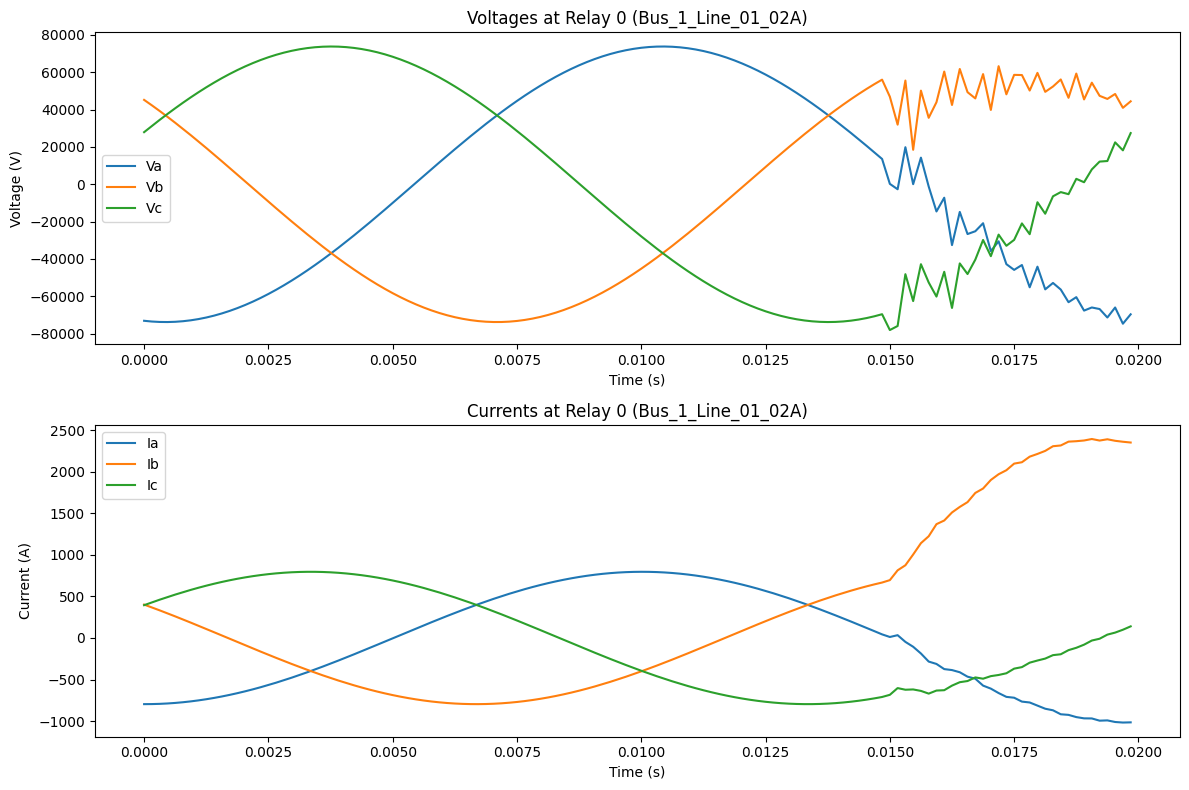

In [31]:
# plot X_relay[0]
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
time_axis = np.arange(X_relay.shape[2]) / config.dataset.sampling_frequency
plt.subplot(2, 1, 1)
plt.plot(time_axis, X_relay[0, 0, :], label="Va")
plt.plot(time_axis, X_relay[0, 1, :], label="Vb")
plt.plot(time_axis, X_relay[0, 2, :], label="Vc")
plt.title("Voltages at Relay 0 (Bus_1_Line_01_02A)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(time_axis, X_relay[0, 3, :], label="Ia")
plt.plot(time_axis, X_relay[0, 4, :], label="Ib")
plt.plot(time_axis, X_relay[0, 5, :], label="Ic")
plt.title("Currents at Relay 0 (Bus_1_Line_01_02A)")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
def line_differential_score(
    Ia_3xT: np.ndarray,
    Ib_3xT: np.ndarray,
    prefault_slice: slice,
    k: float = 0.3,
    imin: float = 0.0,
) -> float:
    """
    Ia_3xT, Ib_3xT: currents [L1,L2,L3] shape (3,T)
    prefault_slice: slice selecting prefault samples to determine polarity
    """
    # choose signs to minimize prefault differential energy
    best = None
    for sa in (+1.0, -1.0):
        for sb in (+1.0, -1.0):
            diff_pf = sa * Ia_3xT[:, prefault_slice] + sb * Ib_3xT[:, prefault_slice]
            e = float(np.mean(diff_pf**2))
            if best is None or e < best[0]:
                best = (e, sa, sb)
    _, sa, sb = best

    Idiff = sa * Ia_3xT + sb * Ib_3xT  # (3,T)
    Idiff_mag = np.linalg.norm(Idiff, axis=0)  # (T,)
    Irest_mag = 0.5 * (np.linalg.norm(Ia_3xT, axis=0) + np.linalg.norm(Ib_3xT, axis=0))

    score = float(np.max(Idiff_mag - k * Irest_mag - imin))
    return score

In [33]:
LINE_PAIRS = {
    "01_02A": (0, 2),  # R1, R3 (0-indexed)
    "01_02B": (1, 3),  # R2, R4
    "02_03A": (4, 6),  # R5, R7
    "02_03B": (5, 7),  # R6, R8
}


def differential_fd_fli(
    X_relays_8x6xT: np.ndarray,
    prefault_slice: slice,
    k: float = 0.3,
    imin: float = 0.0,
    trip_th: float = 0.0,
):
    """
    X_relays channels [Va,Vb,Vc,Ia,Ib,Ic]
    returns (fd_label, fli_label, scores_dict)
    """
    scores = {}
    for line, (ra, rb) in LINE_PAIRS.items():
        Ia = X_relays_8x6xT[ra, 3:6, :]  # currents
        Ib = X_relays_8x6xT[rb, 3:6, :]
        scores[line] = line_differential_score(Ia, Ib, prefault_slice, k=k, imin=imin)

    best_line = max(scores, key=scores.get)
    fd = int(scores[best_line] > trip_th)
    return fd, best_line, scores


prefault_slice = slice(0, 20)  # first 20 samples as prefault
fd_label, fli_label, scores = differential_fd_fli(X_relay, prefault_slice, k=0.3, imin=0.0, trip_th=0.1)
fd_label, fli_label, scores

(1,
 '02_03A',
 {'01_02A': -245.0626703851513,
  '01_02B': 0.0,
  '02_03A': 7634.418444485662,
  '02_03B': -32.040981215566816})

In [38]:
X_relay

array([[[-7.31451641e+04, -7.35469844e+04, -7.37716328e+04, ...,
         -6.60249453e+04, -7.47169297e+04, -6.96734297e+04],
        [ 4.52196836e+04,  4.23019609e+04,  3.92823281e+04, ...,
          4.83875156e+04,  4.09675625e+04,  4.44569766e+04],
        [ 2.79254785e+04,  3.12450273e+04,  3.44893047e+04, ...,
          2.24594492e+04,  1.81900020e+04,  2.74323848e+04],
        [-7.96253418e+02, -7.95498962e+02, -7.92828125e+02, ...,
         -1.01114996e+03, -1.01775555e+03, -1.01547864e+03],
        [ 4.01739868e+02,  3.67522461e+02,  3.32419617e+02, ...,
          2.37264160e+03,  2.36112915e+03,  2.35180762e+03],
        [ 3.94513519e+02,  4.27976532e+02,  4.60408539e+02, ...,
          6.46300964e+01,  9.90753326e+01,  1.39712479e+02]],

       [[-7.31451641e+04, -7.35469844e+04, -7.37716328e+04, ...,
         -6.60249453e+04, -7.47169297e+04, -6.96734297e+04],
        [ 4.52196836e+04,  4.23019609e+04,  3.92823281e+04, ...,
          4.83875156e+04,  4.09675625e+04,  4.44569

In [37]:
labels[12:14]

,dt_start,event_family,event_type,overlap_ratio,sample_id,status,window_duration,window_idx,window_start_time,y_event_present,...,y_fault_location,y_fault_present,y_is_grounded,y_phase_A,y_phase_B,y_phase_C,y_switch_action,y_switch_category,y_switch_present,y_switch_target_bus
12,-0.019892,fault,flt_1phg_shc,0.005385,0,clean,0.02,12,0.40875,0,...,19.547918,0,1,0,1,0,<NA>,<NA>,0,<NA>
13,-0.014892,fault,flt_1phg_shc,0.255385,0,fault_start,0.02,13,0.41375,1,...,19.547918,1,1,0,1,0,<NA>,<NA>,0,<NA>
